In [1]:
from datasets import load_dataset

ds = load_dataset("Quandela/Challenge_Swaptions")
print(ds)

# ds_level1 = load_dataset(
#     "Quandela/Challenge_Swaptions",
#     data_files="level-1_Future_prediction/train.csv",
#     split="train",
# )
# print(ds_level1)

/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25', 'Tenor : 6; Maturity : 0.25', 'Tenor : 7; Maturity : 0.25', 'Tenor : 8; Maturity : 0.25', 'Tenor : 9; Maturity : 0.25', 'Tenor : 10; Maturity : 0.25', 'Tenor : 15; Mat

In [2]:
type(ds['train'])

datasets.arrow_dataset.Dataset

In [3]:
ds['train'].features

{'Date': Value('large_string'),
 'Tenor : 1; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 2; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 3; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 4; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 5; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 6; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 7; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 8; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 9; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 10; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 15; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 20; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 25; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 30; Maturity : 0.0833333333333333': Value('float64'),
 'Tenor : 1; Maturity : 0.25': Value('float64'),
 'Tenor : 2; Maturity : 0.25': V

In [4]:
seed = 42

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import perceval as pcvl
from perceval.components import BS, PS, Circuit
from perceval.backends import BackendFactory

import random
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import torch.nn.functional as functional

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tqdm import tqdm

In [6]:
random.seed(seed)

In [7]:
ds = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

df = pd.DataFrame(ds)
df = df.drop(columns=["Date"])

data = df.values.astype(np.float64)
print("Surface shape:", data.shape)

Surface shape: (494, 224)


In [8]:
df

,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.028565,0.038700,0.040127,0.040762,0.040466,0.038953,0.037553,0.036768,0.036646,0.035595,...,0.331053,0.329056,0.330997,0.324676,0.325758,0.322393,0.345859,0.359162,0.346670,0.337670
1,0.029334,0.039499,0.040982,0.041638,0.041336,0.039815,0.038397,0.037631,0.037504,0.036437,...,0.336319,0.334434,0.336568,0.330244,0.331462,0.328144,0.351816,0.365197,0.350993,0.340822
2,0.028696,0.038816,0.040328,0.041042,0.040804,0.039329,0.037968,0.037216,0.037107,0.036062,...,0.333634,0.331707,0.333800,0.327487,0.328710,0.325436,0.348915,0.362236,0.348652,0.339027
3,0.030854,0.041536,0.043035,0.043605,0.043241,0.041556,0.039977,0.039167,0.038968,0.037793,...,0.336884,0.335106,0.337548,0.331279,0.332811,0.329771,0.353246,0.366100,0.351404,0.340465
4,0.030406,0.041174,0.042681,0.043266,0.042937,0.041253,0.039685,0.038867,0.038667,0.037492,...,0.333249,0.331426,0.333830,0.327580,0.329123,0.326146,0.349390,0.362048,0.348331,0.338022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,0.020498,0.027497,0.029343,0.031089,0.031812,0.031577,0.031602,0.031397,0.031824,0.031444,...,0.337297,0.335116,0.336782,0.330423,0.331625,0.328415,0.351027,0.367999,0.348703,0.341246
490,0.020970,0.028124,0.029974,0.031684,0.032358,0.032068,0.032022,0.031792,0.032194,0.031783,...,0.338839,0.336695,0.338385,0.332014,0.333177,0.329895,0.352712,0.369517,0.350248,0.342360
491,0.021622,0.029038,0.030888,0.032538,0.033144,0.032760,0.032601,0.032328,0.032687,0.032220,...,0.338995,0.336886,0.338615,0.332241,0.333384,0.330063,0.353034,0.369456,0.350729,0.342531
492,0.022761,0.030612,0.032512,0.034111,0.034649,0.034141,0.033833,0.033519,0.033822,0.033274,...,0.340839,0.338845,0.340788,0.334428,0.335700,0.332439,0.355568,0.371336,0.352592,0.343449


In [128]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

r = 5
pca = PCA(n_components=r)
factors = pca.fit_transform(data_scaled)

print("Factor shape:", factors.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Factor shape: (494, 5)
Explained variance: 0.9997859107422642


In [10]:
T = len(factors)
split = int(0.8 * T)

full_train, full_test = factors[:split], factors[split:]

print(len(full_train))
print(len(full_test))

395
99


In [11]:
window = 3

In [12]:
# # -------------------------
# # 1) Scale + PCA on surfaces (fit on train only)
# # -------------------------
# surf_scaler = StandardScaler()
# S_train_scaled = surf_scaler.fit_transform(full_train)
# S_test_scaled  = surf_scaler.transform(full_test)

# d = 12  # latent surface dimension (try 6, 8, 12)
# pca = PCA(n_components=d, random_state=0)
# Z_train = pca.fit_transform(S_train_scaled)   # (T_train, d)
# Z_test  = pca.transform(S_test_scaled)        # (T_test,  d)

Z_train = full_train
Z_test = full_test

# -------------------------
# 2) Build lagged dataset in PCA space
# -------------------------
k = window  # lag length

X_train, Y_train = [], []
for t in range(k, len(Z_train)):
    X_train.append(Z_train[t-k:t])   # (k*d,)
    Y_train.append(Z_train[t])                  # (d,)

X_test, Y_test = [], []
for t in range(k, len(Z_test)):
    X_test.append(Z_test[t-k:t])
    Y_test.append(Z_test[t])

X_train = np.asarray(X_train, dtype="float32")
Y_train = np.asarray(Y_train, dtype="float32")
X_test  = np.asarray(X_test,  dtype="float32")
Y_test  = np.asarray(Y_test,  dtype="float32")

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

# Optional: clip inputs for angle encoding stability
# X_train = np.clip(X_train, -2, 2)
# X_test  = np.clip(X_test,  -2, 2)    # X dim should be ~ (N, 24) if k=3,d=8

X_train: (392, 3, 5) Y_train: (392, 5)
X_test : (96, 3, 5) Y_test : (96, 5)


In [13]:
X_train.shape, Y_train.shape

((392, 3, 5), (392, 5))

### juust some confirmation

In [14]:
X_train[0][-1], Y_train[0], X_train[1][-2]

(array([-20.01351   ,   1.7670473 ,   2.4043527 ,   0.28011534,
         -0.09805918], dtype=float32),
 array([-16.50414   ,   0.83292955,   3.7835512 ,   0.22095448,
          0.08227109], dtype=float32),
 array([-20.01351   ,   1.7670473 ,   2.4043527 ,   0.28011534,
         -0.09805918], dtype=float32))

# A simple classical ESN example

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

class ClassicalESN(nn.Module):
    def __init__(self, n_inputs, n_res, n_outputs, spectral_radius=0.95):
        super(ClassicalESN, self).__init__()
        self.n_res = n_res
        
        # 1. Fixed Input Mapping
        self.W_in = nn.Linear(n_inputs, n_res)
        
        # 2. Fixed Reservoir (Recurrent)
        self.W_res = nn.Linear(n_res, n_res, bias=False)
        
        # 3. Trainable Readout
        self.readout = nn.Linear(n_res, n_outputs)
        
        # Initialize and Freeze Reservoir
        with torch.no_grad():
            nn.init.normal_(self.W_in.weight, std=1.0)
            nn.init.normal_(self.W_res.weight, std=1.0)
            # Scale for spectral radius
            weights = self.W_res.weight
            eigenvalues = torch.linalg.eigvals(weights)
            max_eig = torch.max(torch.abs(eigenvalues))
            self.W_res.weight *= (spectral_radius / max_eig)
        
        # Freeze all except readout
        self.W_in.weight.requires_grad = False
        self.W_res.weight.requires_grad = False

    def forward(self, x_window):
        # x_window shape: (batch, window_size, n_inputs)
        batch_size = x_window.size(0)
        h = torch.zeros(batch_size, self.n_res).to(x_window.device)
        
        # Recurrence through the window
        for t in range(x_window.size(1)):
            u = x_window[:, t, :]
            h = torch.tanh(self.W_in(u) + self.W_res(h))
            
        return self.readout(h)

In [16]:
# --- Training Loop Helper ---
def train_model(model, train_loader, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        history.append(epoch_loss / len(train_loader))
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {history[-1]:.6f}")
    return history

Training Classical ESN...
Epoch 0 | Loss: 42.158740
Epoch 10 | Loss: 9.551782
Epoch 20 | Loss: 7.736429
Epoch 30 | Loss: 7.310147
Epoch 40 | Loss: 7.000573
Epoch 50 | Loss: 6.742867
Epoch 60 | Loss: 6.515135
Epoch 70 | Loss: 6.306256
Epoch 80 | Loss: 6.110704
Epoch 90 | Loss: 5.925839


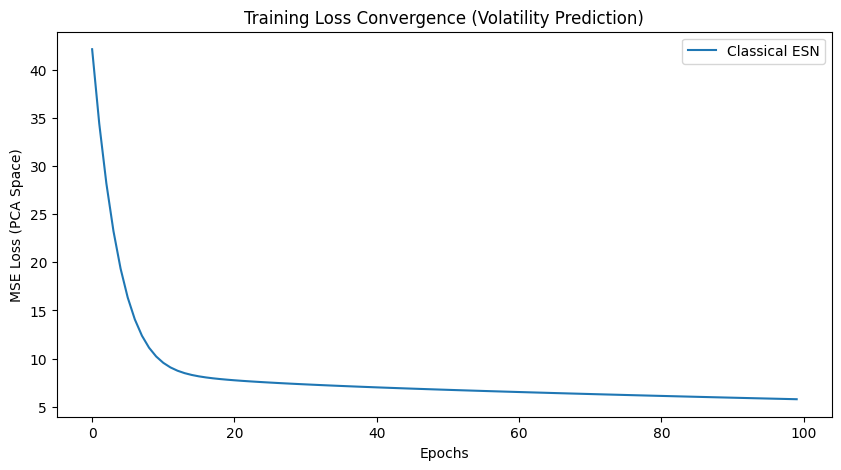

In [56]:
# Assuming you have your PCA-reduced windows in PyTorch Tensors:
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=False)

n_comp = 5 # PCA components
n_res = 200

# Initialize models
classical_esn = ClassicalESN(n_comp, n_res, n_comp)
# For the hackathon, a 'Quantum' reservoir would replace W_res with a MerLin layer
# but you can simulate the complexity by changing initialization/sparsity.

# Train
print("Training Classical ESN...")
esn_history = train_model(classical_esn, train_loader, epochs=100)

# 3. Visualization of Results
plt.figure(figsize=(10, 5))
plt.plot(esn_history, label='Classical ESN')
plt.title('Training Loss Convergence (Volatility Prediction)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (PCA Space)')
plt.legend()
plt.show()

In [57]:
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

In [58]:
classical_esn.eval()

criterion = nn.MSELoss()

y_test_preds = []
y_test_true = []

for x_batch, y_batch in test_loader:
    output = classical_esn(x_batch)
    loss = criterion(output, y_batch)

    # print("loss:", loss)

    Y_pred_np = output.detach().numpy()
    Y_test_np = y_batch.cpu().numpy()

    y_test_preds.append(Y_pred_np)
    y_test_true.append(Y_test_np)

    # Inverse PCA
    Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
    Y_test_surface_scaled = pca.inverse_transform(Y_test_np)

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

    # print("Surface MSE:", surface_mse)

print(criterion(torch.tensor(y_test_preds), torch.tensor(y_test_true)))

tensor(6.3595)


# The quantum circuit

In [59]:
from merlin import ComputationSpace, MeasurementStrategy, QuantumLayer

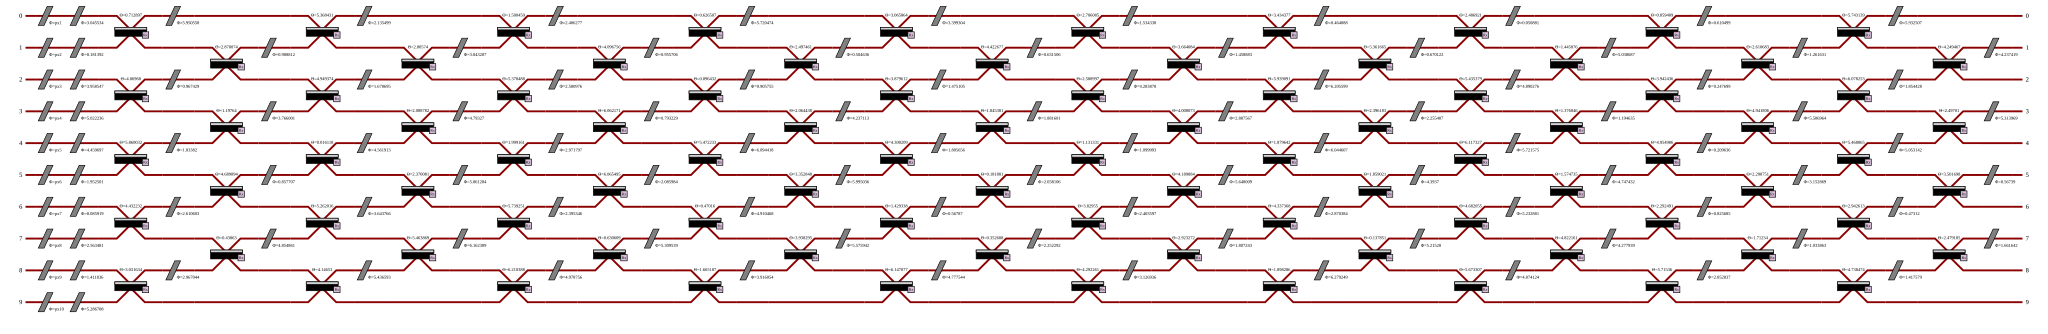

In [60]:
def create_vqc_bs_mesh(m):
    """Create variational quantum classifier with specified number of modes using beam splitter meshes"""

    # BS based circuits from https://perceval.quandela.net/docs/v0.13/notebooks/BS-based_implementation.html
    bs_l = pcvl.GenericInterferometer(
        m,
        lambda idx: (
            pcvl.BS(theta=np.pi * 2 * random.random())
            // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
        ),
        shape=pcvl.InterferometerShape.RECTANGLE,
        depth=2 * m,
        phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
    )

    # Central part of the circuit encodes our data
    c_var = pcvl.Circuit(m)
    for i in range(m):
        px = pcvl.P(f"px{i + 1}")
        # c_var.add(i + (m - 2) // 2, pcvl.PS(px))
        c_var.add(i, pcvl.PS(px))

    # # Other BS mesh
    # bs_r = pcvl.GenericInterferometer(
    #     m,
    #     lambda idx: (
    #         pcvl.BS(theta=pcvl.P(f"theta_r{idx}"))
    #         // (0, pcvl.PS(phi=np.pi * 2 * random.random()))
    #     ),
    #     shape=pcvl.InterferometerShape.RECTANGLE,
    #     depth=2 * m,
    #     phase_shifter_fun_gen=lambda idx: pcvl.PS(phi=np.pi * 2 * random.random()),
    # )

    c = pcvl.Circuit(m)
    c.add(0, c_var, merge=True)
    c.add(0, bs_l, merge=True)
    # c.add(0, bs_r, merge=True)

    return c


def count_parameters(model):
    """Count trainable parameters in a PyTorch model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# In our case, we use 3 modes to have the same experiment set-up as the paper
vqc_bs_mesh = create_vqc_bs_mesh(10)
# Let's visualize our circuit
pcvl.pdisplay(vqc_bs_mesh)

In [61]:
class ScaleLayer(nn.Module):
    """
    Multiply the input tensor by a learned or fixed factor.

    Args:
        dim (int): Dimension of the input data to be encoded.
        scale_type (str): Type of scaling method.

    Returns: nn.Module that multiplies the input tensor by a learned or fixed factor.
    """

    def __init__(self, dim, scale_type="learned"):
        super().__init__()
        # Create a single learnable parameter (initialized to 1.0 by default)
        if scale_type == "learned":
            self.scale = nn.Parameter(torch.rand(dim))
        elif scale_type == "2pi":
            self.scale = torch.full((dim,), 2 * torch.pi)
        elif scale_type == "pi":
            self.scale = torch.full((dim,), torch.pi)
        elif scale_type == "/pi":
            self.scale = torch.full((dim,), 1 / torch.pi)
        elif scale_type == "1":
            self.scale = torch.full((dim,), 1)

    def forward(self, x):
        # Element-wise multiplication of each input element by the learned scale
        return x * self.scale

In [116]:
# def get_vqc(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1"):
class ReservoirCircuit(nn.Module):
    def __init__(self, m, initial_state, input_size, no_bunching=False, activation="none", scale_type="1", reservoir_type=1):
        super().__init__()
        """Build and return the hybrid model used for binary classification of 2D data"""

        # Get vqc circuit
        vqc_circuit = create_vqc_bs_mesh(m)
        n_photons = torch.sum(torch.tensor(initial_state))
        if no_bunching:
            # No bunching: C(n_modes, n_photons)
            comb(m, n_photons)
        else:
            # With bunching: C(n_modes + n_photons - 1, n_photons)
            comb(m + n_photons - 1, n_photons)

        self.input_layer = ScaleLayer(input_size, scale_type=scale_type)
        self.vqc = QuantumLayer(
            input_size=input_size,
            circuit=vqc_circuit,
            # trainable_parameters=[
            #     p.name for p in vqc_circuit.get_parameters() if not p.name.startswith("px")
            # ],
            trainable_parameters=[],
            input_parameters=["px"],
            input_state=initial_state,  # [1, 0, 0] for example
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.UNBUNCHED
                if no_bunching
                else ComputationSpace.FOCK
            ),
        )

        self.activation = activation
        self.reservoir_type = reservoir_type

        self.pre_req = nn.Sequential(self.input_layer, self.vqc)
        self.mid_reservoir = nn.Linear(self.vqc.output_size, input_size//2)
        self.input_size = input_size

        # self.res_final = nn.Linear(self.vqc.output_size, self.input_size//2)
        self.res_final = nn.Linear(self.input_size//2, self.input_size//2)
    
    def forward(self, x):
        x = x[0]
        shape_input = x.shape  # shaoe of x is going to be (window_size, num_PCA_feats)
        window_size = shape_input[0]
        num_PCA_feats = shape_input[1]

        if self.reservoir_type == 1:
            # h_time = torch.zeros(1, num_PCA_feats)
            h_time = torch.zeros(num_PCA_feats)
            for window_idx in range(window_size):
                # y_time = torch.unsqueeze(x[window_idx], 0)
                y_time = x[window_idx]
                # print(y_time.shape, h_time.shape)
                y_time = torch.cat((y_time, h_time), dim=0)
                y_time__ = self.pre_req(y_time)
                # print(y_time_.shape)
                y_time_ = self.mid_reservoir(y_time__)
                # print(y_time_.shape)
                # print(y_time_)
                h_time = torch.squeeze(y_time_, dim=0)

        # The last Linear layer acts as the observable, and it makes sure the output is 1 dimensional
        if self.activation == "none":
            # complete_vqc = self.res_final(y_time__)
            complete_vqc = self.res_final(h_time)
            
            # complete_vqc = nn.Sigmoid()(complete_vqc)
            # complete_vqc = y_time_

        elif self.activation == "none_":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(self.input_layer, self.vqc, classification_layer)

        elif self.activation == "sigmoid":
            classification_layer = nn.Linear(self.vqc.output_size, 1)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Sigmoid()
            )

        elif self.activation == "softmax":
            classification_layer = nn.Linear(self.vqc.output_size, 2)
            complete_vqc = nn.Sequential(
                self.input_layer, self.vqc, classification_layer, nn.Softmax(dim=1)
            )

        else:
            raise ValueError(
                f"Activation function unknown or not implemented: '{self.activation}'"
            )
        
        return complete_vqc

In [117]:
# def get_mlp_deep(input_size, activation):
#     """Build and return a small 2-hidden-layers MLP for binary classification"""
#     classical_layer_1 = nn.Linear(input_size, 2)
#     classical_layer_2 = nn.Linear(2, 3)

#     if activation == "none":
#         mlp = nn.Sequential(
#             classical_layer_1, nn.ReLU(), classical_layer_2, nn.ReLU(), nn.Linear(3, 1)
#         )

#     elif activation == "sigmoid":
#         mlp = nn.Sequential(
#             classical_layer_1,
#             nn.ReLU(),
#             classical_layer_2,
#             nn.ReLU(),
#             nn.Linear(3, 1),
#             nn.Sigmoid(),
#         )

#     elif activation == "softmax":
#         mlp = nn.Sequential(
#             classical_layer_1,
#             nn.ReLU(),
#             classical_layer_2,
#             nn.ReLU(),
#             nn.Linear(3, 2),
#             nn.Softmax(dim=1),
#         )
#     else:
#         raise ValueError(
#             f"Activation function unknown or not implemented: '{activation}'"
#         )

#     return mlp


# def get_mlp_wide(input_size, activation):
#     """Build and return a small 1-hidden-layers MLP for binary classification"""
#     classical_layer_1 = nn.Linear(input_size, 4)

#     if activation == "none":
#         mlp = nn.Sequential(classical_layer_1, nn.ReLU(), nn.Linear(4, 1))

#     elif activation == "sigmoid":
#         mlp = nn.Sequential(classical_layer_1, nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())

#     elif activation == "softmax":
#         mlp = nn.Sequential(
#             classical_layer_1, nn.ReLU(), nn.Linear(4, 2), nn.Softmax(dim=1)
#         )
#     else:
#         raise ValueError(
#             f"Activation function unknown or not implemented: '{activation}'"
#         )

#     return mlp

In [118]:
# def train_model(model, model_name, x_train, x_test, y_train, y_test, args):
#     """Train a model and return training metrics"""
#     optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, betas=args.betas)
#     criterion = nn.MSELoss()  # loss from paper

#     losses = []
#     train_accuracies = []
#     test_accuracies = []

#     model.train()

#     pbar = tqdm(range(args.n_epochs), desc=f"Training {model_name}")
#     for _epoch in pbar:
#         permutation = torch.randperm(x_train.size()[0])
#         total_loss = 0

#         for i in range(0, x_train.size()[0], args.batch_size):
#             indices = permutation[i : i + args.batch_size]
#             batch_x, batch_y = x_train[indices], y_train[indices]

#             # If softmax activation, we have to format the labels in 2-dimensions
#             if args.activation == "softmax":
#                 # One-hot encode
#                 batch_y = functional.one_hot(
#                     batch_y.squeeze().long(), num_classes=2
#                 ).float()  # shape : (batch_size, 2)

#             outputs = model(batch_x)

#             # Get the right parameters for regularization
#             if args.regu_on == "linear":
#                 # Get the observable parameters
#                 if args.activation == "none":
#                     obs = list(model[-1].parameters())
#                 else:
#                     obs = list(model[-2].parameters())
#                 # Flatten all tensors and concatenate into a single vector
#                 obs_vector = torch.cat([p.view(-1) for p in obs])

#             elif args.regu_on == "all":
#                 # Get the observable parameters
#                 obs = list(model.parameters())
#                 # Flatten all tensors and concatenate into a single vector
#                 obs_vector = torch.cat([p.view(-1) for p in obs])

#             else:
#                 raise NotImplementedError

#                 #  [                      MSE                    ] + [                regularization                    ]
#             loss = (
#                 criterion(outputs.squeeze(), batch_y.squeeze())
#                 + args.alpha * torch.linalg.vector_norm(obs_vector) ** 2
#             )

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()

#         avg_loss = total_loss / (x_train.size()[0] // args.batch_size)
#         losses.append(avg_loss)

#         # Evaluation
#         model.eval()
#         with torch.no_grad():
#             train_outputs = model(x_train)

#             if args.activation == "softmax":
#                 train_preds = torch.argmax(train_outputs, dim=1)
#             else:
#                 train_preds = torch.round(train_outputs)

#             train_acc = accuracy_score(y_train.numpy(), train_preds.cpu().numpy())
#             train_accuracies.append(train_acc)

#             test_outputs = model(x_test)

#             if args.activation == "softmax":
#                 test_preds = torch.argmax(test_outputs, dim=1)
#             else:
#                 test_preds = torch.round(test_outputs)

#             test_acc = accuracy_score(y_test.numpy(), test_preds)
#             test_accuracies.append(test_acc)

#             pbar.set_description(
#                 f"Training {model_name} - Loss: {avg_loss:.4f}, Test Acc: {test_acc:.4f}"
#             )

#         model.train()

#     return {
#         "losses": losses,
#         "train_accuracies": train_accuracies,
#         "test_accuracies": test_accuracies,
#         "final_test_acc": test_accuracies[-1],
#     }

In [119]:
# def train_model_multiple_runs(type, args):
#     """
#     Train model multiple times and return results

#     Parameters
#     ----------
#     type : String, must be in this list ["vqc", "mlp_deep", "mlp_wide", "svm_lin", "svm_rbf"]
#         Indicates which type of model to train.

#     args : Arguments object
#         Contains arguments passed to the model or useful for training

#     Returns
#     -------
#     Dictionary
#         Contains the results of several runs of the model.
#     """

#     x_trains, x_tests, y_trains, y_tests = prepare_data()
#     datasets = ["linear", "circular", "moon"]
#     best_models = []
#     best_accs = []
#     results = {}

#     for i, dataset in enumerate(datasets):
#         x_train = x_trains[i]
#         x_test = x_tests[i]
#         y_train = y_trains[i]
#         y_test = y_tests[i]

#         if type == "vqc":
#             print(f"\nTraining VQC with dataset {dataset} ({args.num_runs} runs):")
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = get_vqc(
#                     args.m,
#                     args.initial_state,
#                     activation=args.activation,
#                     no_bunching=args.no_bunching,
#                     scale_type=args.scale_type,
#                 )
#                 num_params = count_parameters(model)

#                 print(
#                     f"  Run {run + 1}/{args.num_runs}, VQC has {num_params} parameters..."
#                 )
#                 args.set_dataset_name(dataset)

#                 run_results = train_model(
#                     model,
#                     f"VQC with dataset {dataset} (run{run + 1})",
#                     x_train,
#                     x_test,
#                     y_train,
#                     y_test,
#                     args,
#                 )
#                 models.append(model)
#                 model_runs.append(run_results)

#         elif type[:3] == "mlp":
#             if type == "mlp_wide":
#                 network_type = "wide"
#                 get_mlp = get_mlp_wide
#             elif type == "mlp_deep":
#                 network_type = "deep"
#                 get_mlp = get_mlp_deep
#             else:
#                 raise NotImplementedError

#             print(
#                 f"\nTraining MLP ({network_type}) with dataset {dataset} ({args.num_runs} runs):"
#             )
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = get_mlp(2, activation=args.activation)

#                 num_params = count_parameters(model)

#                 print(
#                     f"  Run {run + 1}/{args.num_runs}, MLP has {num_params} parameters..."
#                 )
#                 args.set_dataset_name(dataset)
#                 run_results = train_model(
#                     model,
#                     f"MLP with dataset {dataset} (run{run + 1})",
#                     x_train,
#                     x_test,
#                     y_train,
#                     y_test,
#                     args,
#                 )
#                 models.append(model)
#                 model_runs.append(run_results)

#         else:
#             if type == "svm_lin":
#                 kernel = "linear"
#             elif type == "svm_rbf":
#                 kernel = "rbf"
#             else:
#                 raise NotImplementedError

#             print(
#                 f"\nTraining SVM ({kernel}) with dataset {dataset} ({args.num_runs} runs):"
#             )
#             models = []
#             model_runs = []

#             for run in range(args.num_runs):
#                 # Create a fresh instance of the model for each run
#                 model = SVC(kernel=kernel, gamma="scale")
#                 model.fit(x_train, y_train)

#                 print(f"  Run {run + 1}/{args.num_runs}, SVM ({kernel})...")
#                 args.set_dataset_name(dataset)

#                 y_pred = model.predict(x_test)
#                 accuracy = accuracy_score(y_test, y_pred)
#                 models.append(model)
#                 run_results = {
#                     "losses": [0.0] * args.n_epochs,
#                     "train_accuracies": [0.0] * args.n_epochs,
#                     "test_accuracies": [0.0] * args.n_epochs,
#                     "final_test_acc": accuracy,
#                 }
#                 model_runs.append(run_results)

#         best_run = torch.argmax(
#             torch.Tensor([run["final_test_acc"] for run in model_runs])
#         )
#         best_accs.append(
#             torch.max(torch.Tensor([run["final_test_acc"] for run in model_runs]))
#         )
#         best_models.append(models[best_run])

#         # Store all runs for this model
#         results[dataset] = {
#             "runs": model_runs,
#             # Calculate aggregate statistics
#             "avg_final_test_acc": sum(run["final_test_acc"] for run in model_runs)
#             / args.num_runs,
#         }

#     # visualize_decision_boundary(
#     #     type, best_models, x_trains, x_tests, y_trains, y_tests, args, best_accs
#     # )

#     return results


# def train_vqc_multiple_runs(args):
#     """Train VQC several times"""
#     return train_model_multiple_runs("vqc", args)

In [120]:
# Hyperparameters and experimental set-up
m = 10
initial_state = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

activation = "none"  # ["none", "sigmoid", "softmax"]
no_bunching = False
num_runs = 5
n_epochs = 150
batch_size = 30
lr = 0.02
alpha = 0.0002
betas = (0.8, 0.999)
scale_type = "1"  # ["learned", "2pi", "pi", "/pi", "1"]
regu_on = "linear"  # ["linear", "all"]
input_size = 10

In [121]:
class Arguments:
    def __init__(
        self,
        m,
        initial_state,
        activation="none",
        no_bunching=False,
        num_runs=5,
        n_epochs=50,
        batch_size=32,
        lr=0.02,
        alpha=0.2,
        betas=(0.9, 0.999),
        scale_type="learned",
        regu_on="linear",
    ):
        self.m = m
        self.initial_state = initial_state
        self.activation = activation
        self.no_bunching = no_bunching
        self.num_runs = num_runs
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.alpha = alpha
        self.betas = betas
        self.scale_type = scale_type
        self.regu_on = regu_on
        self.dataset_name = ""

    def set_dataset_name(self, dataset):
        self.dataset_name = dataset
        return

In [122]:
# VQC [1, 0, 0]
args = Arguments(
    m,
    initial_state,
    activation,
    no_bunching,
    num_runs,
    n_epochs,
    batch_size,
    lr,
    alpha,
    betas,
    scale_type,
    regu_on,
)

In [123]:
# vqc_100_results = train_vqc_multiple_runs(args)

In [124]:
n_comp = 5 # PCA components
n_res = 200

QuantumRes = ReservoirCircuit(m, initial_state, input_size, no_bunching=False, activation="none", scale_type="2pi", reservoir_type=1)

In [125]:
count_parameters(QuantumRes)

10045

Training Quantum Reservoir...
Epoch 0 | Loss: 46.035999


/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 5])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([8, 5])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 10 | Loss: 45.960220
Epoch 20 | Loss: 45.933591
Epoch 30 | Loss: 45.911402
Epoch 40 | Loss: 45.893086
Epoch 50 | Loss: 45.878094
Epoch 60 | Loss: 45.865910
Epoch 70 | Loss: 45.856074
Epoch 80 | Loss: 45.848176
Epoch 90 | Loss: 45.841865


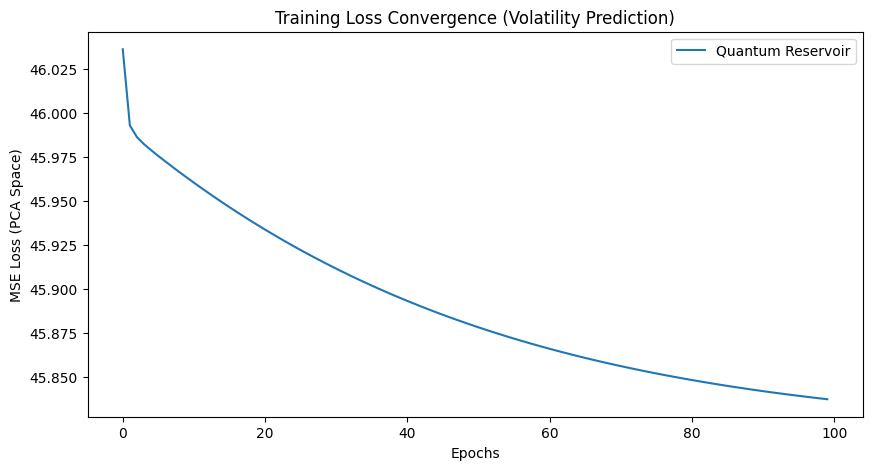

In [140]:
# For the hackathon, a 'Quantum' reservoir would replace W_res with a MerLin layer
# but you can simulate the complexity by changing initialization/sparsity.

# Train
print("Training Quantum Reservoir...")
esn_history = train_model(QuantumRes, train_loader, epochs=100)

# 3. Visualization of Results
plt.figure(figsize=(10, 5))
plt.plot(esn_history, label='Quantum Reservoir')
plt.title('Training Loss Convergence (Volatility Prediction)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (PCA Space)')
plt.legend()
plt.show()

In [139]:
QuantumRes.eval()

criterion = nn.MSELoss()

y_test_preds = []
y_test_true = []

for x_batch, y_batch in test_loader:
    output = QuantumRes(x_batch)

    # loss = criterion(output, y_batch)
    loss = criterion(output.view(-1), y_batch.view(-1))

    # print("loss:", loss)

    Y_pred_np = output.detach().numpy()
    Y_test_np = y_batch.cpu().numpy()

    # print(Y_pred_np.shape)

    y_test_preds.append(Y_pred_np)
    y_test_true.append(Y_test_np)

    # Inverse PCA
    # Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
    # Y_test_surface_scaled = pca.inverse_transform(Y_test_np)
    Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np.reshape(1, -1))
    Y_test_surface_scaled = pca.inverse_transform(Y_test_np.reshape(1, -1))

    # Undo scaling
    Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
    Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

    surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

    print("Surface MSE:", surface_mse)

print(criterion(torch.tensor(y_test_preds), torch.tensor(y_test_true)))

Surface MSE: 0.0005477916742266165
Surface MSE: 0.0006146070723045142
Surface MSE: 0.0005721009617339145
Surface MSE: 0.0004251919799813418
Surface MSE: 0.00047249241867583736
Surface MSE: 0.0002860100103470918
Surface MSE: 0.00021944882152957716
Surface MSE: 0.00038493673596917726
Surface MSE: 0.0002161498787400394
Surface MSE: 0.00010430182792199388
Surface MSE: 6.474263174170452e-05
Surface MSE: 7.855585584375731e-05
Surface MSE: 0.00012882548847259118
Surface MSE: 0.00016390215055765446
Surface MSE: 0.00022313131151902794
Surface MSE: 0.00019400155903491218
Surface MSE: 0.00014738069867336663
Surface MSE: 0.0002637448782879635
Surface MSE: 0.00017223010266509645
Surface MSE: 0.00023937682735354504
Surface MSE: 0.00028344108459725964
Surface MSE: 0.00034293343660893105
Surface MSE: 0.00025783433002528886
Surface MSE: 0.00024245895980211154
Surface MSE: 0.00026526854338254066
Surface MSE: 0.00025277659350423634
Surface MSE: 0.00015548242102539567
Surface MSE: 0.00012585129123644922
S

/Users/soardr/Q-volution 2026/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([96, 1, 5])) that is different to the input size (torch.Size([96, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
